Model Accuracy: 100.0%
Prediction for age 60: 1 (1 = Will Buy)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


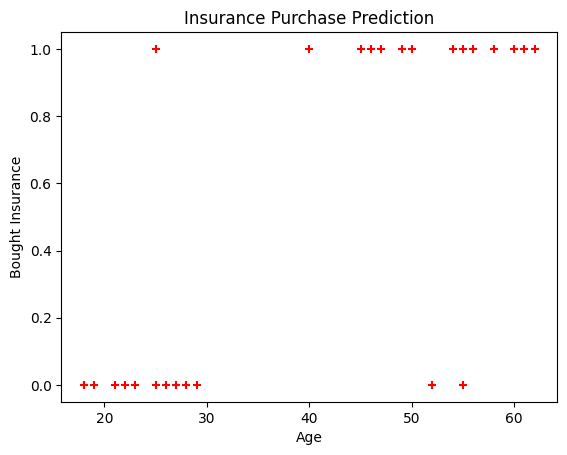

In [11]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset
df = pd.read_csv('insurance_data.csv')

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(df[['age']], df.bought_insurance, train_size=0.9, random_state=10)

# Train Model
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy and Prediction
print(f"Model Accuracy: {model.score(X_test, y_test) * 100}%")
print(f"Prediction for age 60: {model.predict([[60]])[0]} (1 = Will Buy)")

# Plotting
plt.scatter(df.age, df.bought_insurance, marker='+', color='red')
plt.xlabel('Age')
plt.ylabel('Bought Insurance')
plt.title('Insurance Purchase Prediction')
plt.show()

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Load dataset (Ensure HR_comma_sep.csv is uploaded)
df_hr = pd.read_csv('HR_comma_sep.csv')

# Preprocessing: Select variables with direct impact
# We use satisfaction_level, average_montly_hours, promotion, and encoded salary
subdf = df_hr[['satisfaction_level', 'average_montly_hours', 'promotion_last_5years', 'salary']]
salary_dummies = pd.get_dummies(subdf.salary, prefix="salary")
df_with_dummies = pd.concat([subdf, salary_dummies], axis='columns').drop('salary', axis='columns')

X = df_with_dummies
y = df_hr.left

# Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)
hr_model = LogisticRegression(max_iter=1000)
hr_model.fit(X_train, y_train)

print(f"HR Model Accuracy: {hr_model.score(X_test, y_test) * 100:.2f}%")

HR Model Accuracy: 77.38%


In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load Iris dataset
iris = pd.read_csv('iris (1).csv')

# Features and Target
X = iris.drop('species', axis='columns')
y = iris.species

# Train Model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model_iris = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=200)
model_iris.fit(X_train, y_train)

# Evaluate
y_pred = model_iris.predict(X_test)
print(f"Iris Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Iris Model Accuracy: 96.67%


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


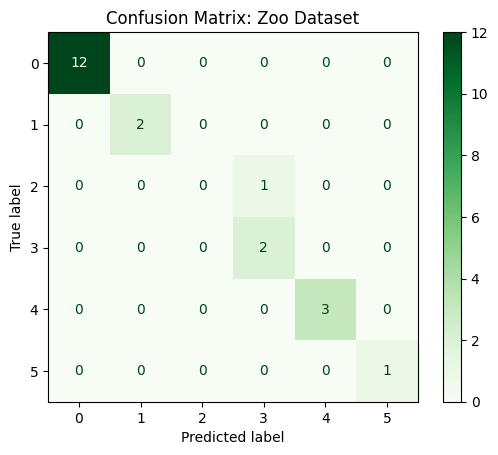

Zoo Accuracy: 95.24%


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# Load Zoo dataset
zoo = pd.read_csv('zoo-data.csv')

# Preprocessing: Drop 'animal_name'
X = zoo.drop(['animal_name', 'class_type'], axis=1)
y = zoo['class_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Model
zoo_model = LogisticRegression(multi_class='multinomial', max_iter=500)
zoo_model.fit(X_train, y_train)

# Confusion Matrix
y_pred = zoo_model.predict(X_test)
cm = metrics.confusion_matrix(y_test, y_pred)
disp = metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix: Zoo Dataset")
plt.show()

print(f"Zoo Accuracy: {metrics.accuracy_score(y_test, y_pred) * 100:.2f}%")

In [15]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softmax(z):
    exp_z = np.exp(z)
    return exp_z / exp_z.sum()

# 1. Sigmoid Calculation (7 hours, a0=-5, a1=0.8)
z_val = -5 + (0.8 * 7)
prob = sigmoid(z_val)
print(f"--- Sigmoid Question ---")
print(f"Z: {z_val}, Probability: {prob:.4f}")
print(f"Result: PASS" if prob >= 0.5 else "FAIL")

# 2. Softmax Calculation for z = [2, 1, 0]
z_vector = np.array([2, 1, 0])
probs = softmax(z_vector)
print(f"\n--- Softmax Question ---")
print(f"Class Probabilities: {probs}")

--- Sigmoid Question ---
Z: 0.6000000000000005, Probability: 0.6457
Result: PASS

--- Softmax Question ---
Class Probabilities: [0.66524096 0.24472847 0.09003057]
